In [55]:
import matplotlib.pyplot as plt
import math
import numpy as np 
from numpy import exp
from scipy.optimize import curve_fit
import pandas as pd
from lmfit import Model, conf_interval, minimize, Minimizer, Parameter, Parameters, report_fit
import h5py
from scipy.signal import savgol_filter
from scipy.integrate import cumtrapz
from scipy.signal import butter, lfilter, freqz, find_peaks
from astropy import units as u
from plasmapy.diagnostics.langmuir import Characteristic, swept_probe_analysis, extract_exponential_section, get_electron_temperature, get_ion_density_LM, get_ion_saturation_current, get_electron_saturation_current, get_electron_density_LM


### Functions to be used in calcualting theoretical dispersion relation and damped wave fit

In [341]:
def whistler(k_para, B, n_e):
    e = 1.602*(10**(-19)) #colombs
    m_e = 9.1*(10**(-31)) #kg
    epsilon_0 = 8.85*(10**(-12))
    c = 3*(10**8)
    w_ce = (e*B)/m_e
    w_pe = np.sqrt((n_e*(e**2))/(m_e*epsilon_0))
    d_e = c/w_pe
    return w_ce*(((k_para*d_e)**2)/(1 + (k_para*d_e)**2))


def damped_wave(z, gamma, omega, t, a):
    result = a*np.exp(-z*gamma)*np.cos(omega*t)
    return result


### Read in a data file and see what the raw data looks like

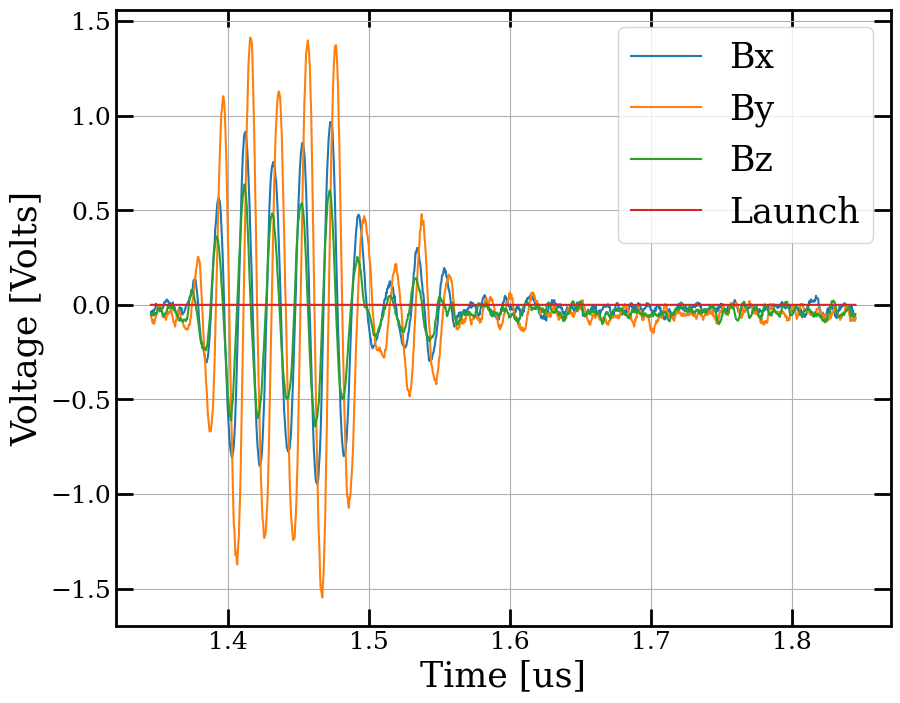

In [311]:
file_name = 'Whistler_Data/zline_RF300V_80G_1mTorr_tt500us_50MHz_2-28-2025.hdf5'

file = h5py.File(file_name, 'r') 
dBx = file["/Acquisition/LeCroy_scope/Channel1"]
dBy = file["/Acquisition/LeCroy_scope/Channel2"]
launch = file["/Acquisition/LeCroy_scope/Channel3"]
dBz = file["/Acquisition/LeCroy_scope/Channel4"]


time = file["/Acquisition/LeCroy_scope/time"]
positions = file["/Control/Positions/positions_setup_array"]

time = np.array(time[:])

fig, ax = plt.subplots(figsize = (10, 8))

f = np.linspace(40, 120, 9)*(10**(6))
w = f*(2*np.pi)


plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
ax.tick_params(which='minor', top = True, direction = 'in', length = 6, width = 2, right = True, labelsize = 18)
ax.tick_params(which='major', top = True, direction = 'in', length = 12, width = 2, right = True, labelsize = 18)
plt.setp(ax.spines.values(), linewidth=2)

plt.plot(time*1000000, dBx[0], label = 'Bx')
plt.plot(time*1000000, dBy[0], label = 'By')
plt.plot(time*1000000, dBz[0], label = 'Bz')
plt.plot(time*1000000, launch[0], label = 'Launch')
plt.xlabel('Time [us]', fontsize = 25)
plt.ylabel('Voltage [Volts]', fontsize = 25)
plt.legend(fontsize = 25)
plt.grid()
plt.savefig('Voltage_Signal_-5cm.pdf')





C:\Users\Demon\AppData\Local\Temp\ipykernel_22556\347599472.py:13: RuntimeWarning: overflow encountered in exp
  result = a*np.exp(-z*gamma)*np.cos(omega*t)


[0.05027354949579228, 0.0507961574506607, 0.04451282382545234, 0.06230066524428516, 0.03818763287798495, 0.07263116261839074, 0.06718664446937982, 0.08272382107104942, 0.0469056321286707]


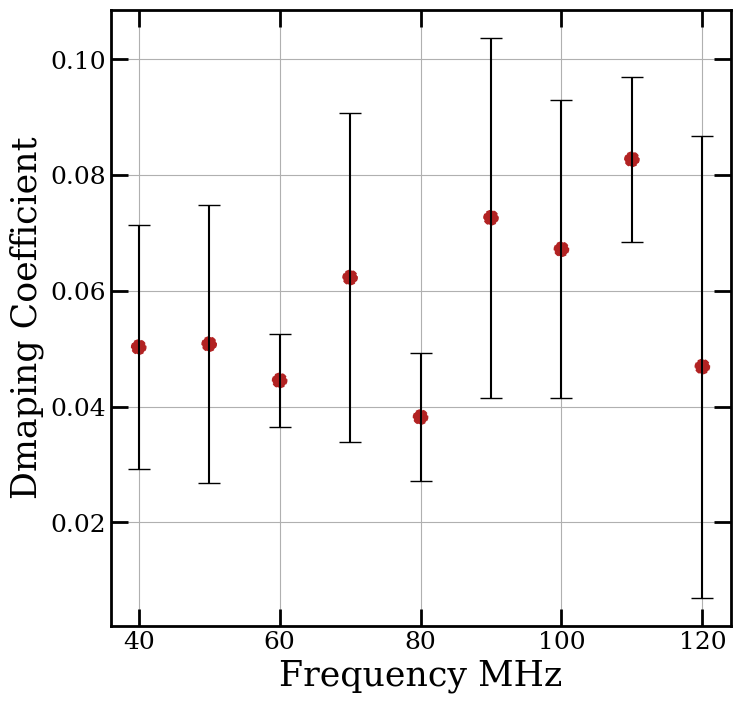

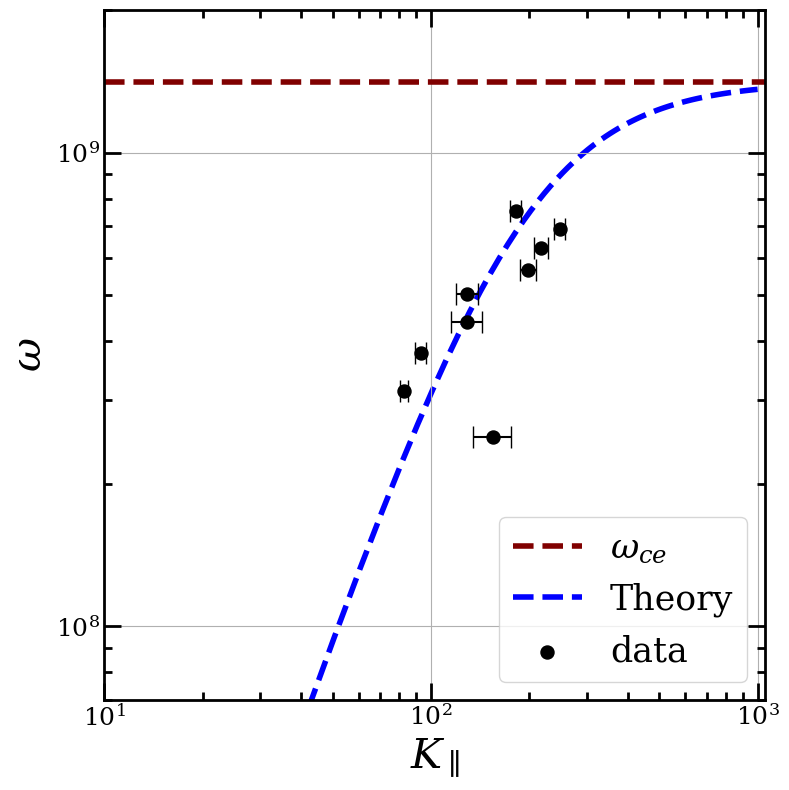

In [431]:
prefix = 'Whistler_Data/zline_RF300V_80G_1mTorr_tt500us_'
suffix = 'MHz_2-28-2025.hdf5'

data = ['40', '50', '60', '70', '80', '90', '100', '110', '120']



#Area and radius of probe
r = 1.3*(10**(-3))
A = np.pi*(r**2)

#Linear and angular Frequency
f = np.linspace(40, 120, 9)*(10**(6))
w = f*(2*np.pi)

#Wavelength array
l = []
lerr = []
#Machine length
x = np.linspace(5, 50, 91)


beesknees = [310, 310, 310, 334, 245, 200, 355, 270, 295]
damp = []
damperr = []
for i in range(9):
    file_name = prefix + data[i] + suffix 
    file = h5py.File(file_name, 'r') 
    dBx = file["/Acquisition/LeCroy_scope/Channel1"]
    dBy = file["/Acquisition/LeCroy_scope/Channel2"]
    launch = file["/Acquisition/LeCroy_scope/Channel3"]
    dBz = file["/Acquisition/LeCroy_scope/Channel4"]


    time = file["/Acquisition/LeCroy_scope/time"]
    positions = file["/Control/Positions/positions_setup_array"]

    time = np.array(time[:])

    Bx = (dBx / (A*w[i]))*10000
    By = (dBy / (A*w[i]))*10000
    Bz = (dBz / (A*w[i]))*10000

    x = np.linspace(5, 50, 91)
    peaks = find_peaks(By[:, beesknees[i]])
    


    #plt.plot(x, By[:, beesknees[i]], label = 'By')
    popt, pcov = curve_fit(damped_wave, x[peaks[0]], By[peaks[0], beesknees[i]])





    l.append(np.mean(np.diff(x[peaks[0]])))
    lerr.append(np.std(np.diff(x[peaks[0]])))
    damp.append(popt[0])
    damperr.append(np.sqrt(np.diag(pcov))[0])
    #popt, pcov = curve_fit(damped_wave, x[peaks[0]], By[peaks[0], 300])
print(damp)

fig, ax = plt.subplots(figsize = (8, 8))
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
ax.tick_params(which='minor', top = True, direction = 'in', length = 6, width = 2, right = True, labelsize = 18)
ax.tick_params(which='major', top = True, direction = 'in', length = 12, width = 2, right = True, labelsize = 18)
plt.setp(ax.spines.values(), linewidth=2)
plt.scatter(f/(10**6), damp, color = 'firebrick', linestyle = 'dashed', s = 105)
plt.errorbar(f/(10**6), damp, yerr = damperr, fmt = 'none', capsize = 8, color = 'black')
plt.xlabel('Frequency MHz', fontsize = 25)
plt.ylabel('Dmaping Coefficient', fontsize = 25)
plt.grid()
plt.savefig('Damping.pdf')

#310 for i=0, 1, 2, 3
#230 for i = 4
#200 for i = 5
#355 for i = 6
#280 for i = 7, 8

l = (np.array(l))*(10**(-2))
l_ex = (np.linspace(0.1, 1000, 100))
lerr = np.array(lerr)




w_ex = whistler(l_ex, 0.008, 1*(10**(18)))


fig, ax = plt.subplots(figsize = (8, 8))
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
ax.tick_params(which='minor', top = True, direction = 'in', length = 6, width = 2, right = True, labelsize = 18)
ax.tick_params(which='major', top = True, direction = 'in', length = 12, width = 2, right = True, labelsize = 18)
plt.setp(ax.spines.values(), linewidth=2)
e = 1.602*(10**(-19)) #colombs
m_e = 9.1*(10**(-31)) #kg
B = 0.008
w_ce = (e*B)/m_e

plt.axhline(w_ce, linestyle = 'dashed', linewidth = 4, color = 'maroon', label = r'$\omega_{ce}$')
plt.plot(l_ex, w_ex, zorder =1, linewidth = 4, linestyle ='dashed', color = 'blue', label = 'Theory')
plt.scatter((2*np.pi)/l, w, zorder = 1, s = 88, color = 'black', label = 'data')
plt.errorbar((2*np.pi)/l, w, xerr = lerr*(2*np.pi), fmt = 'none', capsize = 8, color = 'black')
plt.xlim(10)
plt.ylim(7e7, 2e9)
plt.grid()
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$K_{\parallel}$', fontsize = 30)
plt.ylabel(r'$\omega$', fontsize = 30)
plt.legend(loc = 'lower right', fontsize = 25)
plt.tight_layout()
plt.savefig('Dispersion_Plot.pdf')





No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


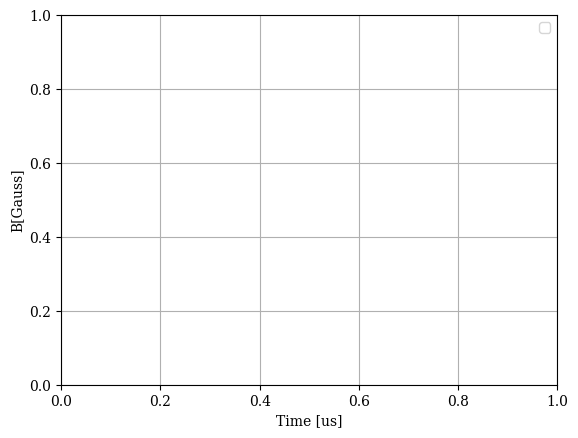

In [329]:
r = 1.3*(10**(-3))
A = np.pi*(r**2)

Bx = (dBx / (A*w[0]))*10000
By = (dBy / (A*w[0]))*10000
Bz = (dBz / (A*w[0]))*10000
#plt.plot(time[:]*1000000, Bx[0], label = 'Bx')
#plt.plot(time[:]*1000000, By[0], label = 'By')
#plt.plot(time[:]*1000000, Bz[0], label = 'Bz')
plt.ylabel('B[Gauss]')
plt.xlabel('Time [us]') 
plt.legend()
plt.grid()


C:\Users\Demon\AppData\Local\Temp\ipykernel_22556\347599472.py:13: RuntimeWarning: overflow encountered in exp
  result = a*np.exp(-z*gamma)*np.cos(omega*t)


[ 9.27814371e-02 -1.42275665e+01 -1.42275665e+01  9.32571231e+01]


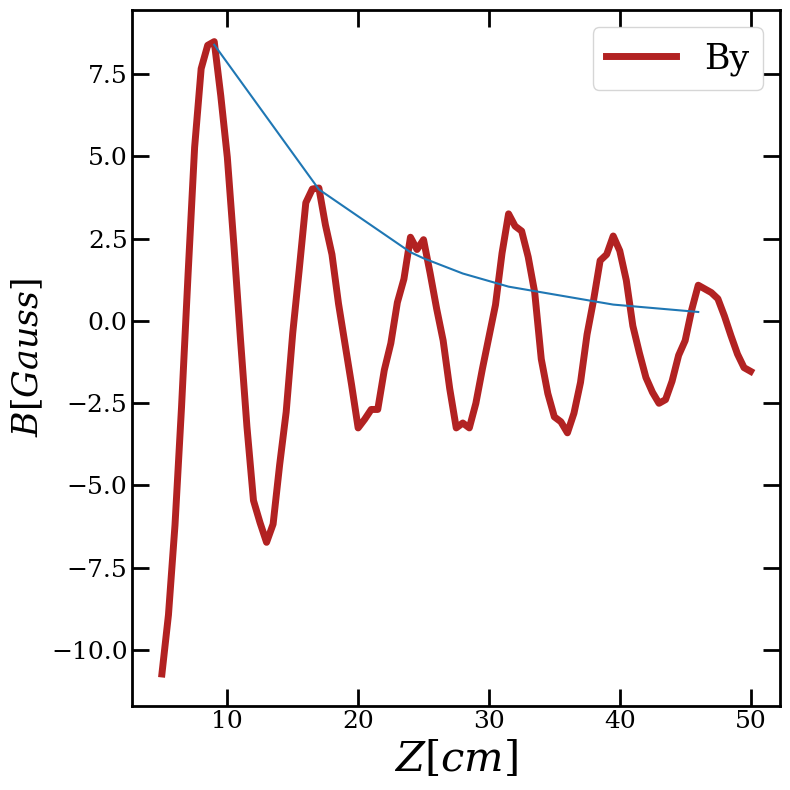

In [342]:
x = np.linspace(5, 50, 91)


peaks = find_peaks(By[:, 300])

popt, pcov = curve_fit(damped_wave, x[peaks[0]], By[peaks[0], 300])

fig, ax = plt.subplots(figsize = (8, 8))
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
ax.tick_params(which='minor', top = True, direction = 'in', length = 6, width = 2, right = True, labelsize = 18)
ax.tick_params(which='major', top = True, direction = 'in', length = 12, width = 2, right = True, labelsize = 18)
plt.setp(ax.spines.values(), linewidth=2)

peaks = find_peaks(By[:, 300])

plt.plot(x, By[:, 300], linewidth = 5,  color = 'firebrick', label = 'By')
plt.plot(x[peaks[0]], damped_wave(x[peaks[0]], *popt))
plt.xlabel(r'$Z [cm]$', fontsize = 30)
plt.ylabel(r'$B[Gauss]$', fontsize = 25)
plt.legend(loc = 'upper right', fontsize = 25)
plt.tight_layout()
plt.savefig('Whistler_Plot.pdf')
print(popt)



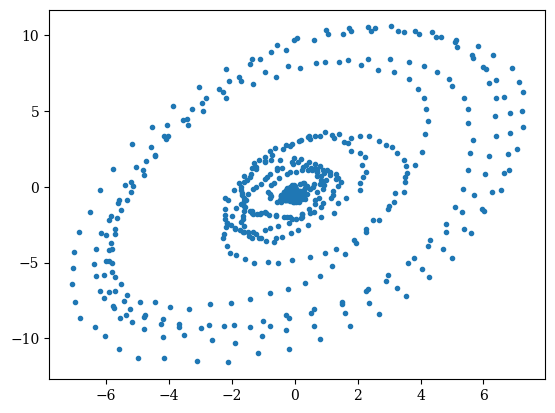

In [331]:
plt.scatter(Bx[0, :600], By[0, :600], marker='.')